# Finding model limitiations
This notebook is meant to generate plots of cases where inference goes badly, mostly due to inputs not matching the training data and/or model assumptions

In [1]:
import os
import sys

from corner import corner

sys.path.append('..')

from src.simulator import Model, BurstSimulator
from src.flow_matching.simulator import Model as BatchedModel

from src.c2st import c2st
from src.flow_matching.loader import empty_classifier_from_config, empty_model_from_config, read_config, prob_path_from_config
from src.flow_matching.distributions import UniformPrior, CompositePrior, Posterior, DiscreteUniform
from src.flow_matching.probability_path import GuidedLinearProbabilityPath
from src.flow_matching.integration import EulerODESolver
from src.flow_matching.models import MLPGuidedVectorField, FRBLightCurveCNN, LightCurveThinner, fourier_embedding, LightCurveMLP, UNetEncoder, TransdimensionalModel, EncodedClassifier
from src.flow_matching.transformer import TransformerGuidedField
from src.helpers import record_every, plot_posterior_samples, gen_parameter_labels

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.lines as mlines

import numpy as np
import pandas as pd
import torch
import yaml

from src.flow_matching.plotting import plot_loss, plot_snapshots
from src.flow_matching.helpers import choose_device, build_mlp, find_run_dir

device = choose_device()

In [ ]:
# fill in desired job_id or directory name 
job_id = "15101905"#"15055684" #False
run_dir = None
save_dir = "../checkpoints/"

# loading the model (via run_id, or path)
run_dir = find_run_dir(job_id, save_dir) if job_id else os.path.join(save_dir, run_dir)

checkpoint_path = os.path.join(run_dir, 'training_checkpoint.pth')
config_path     = os.path.join(run_dir, 'config.yaml')

# create empty model from config
config = read_config(config_path)
vector_field = empty_model_from_config(config)

In [3]:
transdimensional = not config['training']['fixed_N'] #False
print(transdimensional)
if transdimensional:
    classifier = empty_classifier_from_config(config)
    vector_field = TransdimensionalModel(classifier, vector_field)

True


In [4]:
# load trained model 
print(checkpoint_path)
checkpoint = torch.load(checkpoint_path, weights_only=False)

# Load 'normal' or EMA version 
ema = True
if ema:
    EMA_checkpoint_path = os.path.join(run_dir, "EMA_checkpoint.pth")
    state_dict = torch.load(EMA_checkpoint_path, weights_only=False)
    vector_field.load_state_dict(state_dict) 
else:
    vector_field.load_state_dict(checkpoint["model_state_dict"])

vector_field.eval()
vector_field.to(device)

losses = checkpoint["losses"]

../checkpoints/15101905_run_04_10_1723/training_checkpoint.pth


In [ ]:
path = prob_path_from_config(config)
inf_params = config['model']['init_params']['inf_params']
N = path.p_data.model_params['ncomp']
vector_dim = N * len(inf_params)
burstparams = path.p_data.model_params['burstparams']

try:
    mean, std = torch.tensor(config['training']['sample_mean'], device=device), torch.tensor(config['training']['sample_std'], device=device)
except KeyError:
    mean, std = torch.zeros(vector_dim, device=device), torch.ones(vector_dim, device=device)

path.p_data.N_prior.device = device
path.p_data.device = device
path.p_simple.device = device
path.p_data.prior.device = device
path.p_data.prior.set_prior_device()

In [6]:
def downsample(profile, factor=1):
    """
    Reduce time resolution by merging bins.
    """
    for i in range(factor):
        bins_1 = profile[::2]
        bins_2 = profile[1::2]
        if len(bins_1) != len(bins_2):
            bins_1_new = torch.zeros_like(bins_2)
            bins_1_new = bins_1[:-1]
            bins_1 = bins_1_new
        profile = bins_1 + bins_2
    return profile 

In [88]:
from copy import deepcopy

K = 500
t_max = 1.0
TIME = torch.linspace(0, t_max, K)
YBKG = 0.0
 
# standard burst parameter values when not sampled from prior
AMP  = 15
RISE = 0.03
SKEW = 3
N = 2

BURSTPARAMS = {
    't0'   : torch.linspace(0.2, t_max - 0.3, N).unsqueeze(0),
    'amp'  : torch.Tensor([np.log10(AMP)]).repeat(N).unsqueeze(0),
    'rise' : torch.Tensor([np.log10(RISE)]).repeat(N).unsqueeze(0),
    'skew' : torch.Tensor([SKEW]).repeat(N).unsqueeze(0)
}

MODELPARAMS = {
    'time' : TIME,
    'ncomp': N,
    'burstparams': BURSTPARAMS,
    'ybkg': YBKG
}

ncomp = torch.tensor([N], device=device).unsqueeze(0)
simulated_profile = BatchedModel(
            time=MODELPARAMS['time'], 
            ncomp=ncomp, 
            ybkg=MODELPARAMS['ybkg'], 
            burstparams=BURSTPARAMS,
            device=device
            ).get_flux()[0]

noisy_profile = simulated_profile + torch.randn_like(simulated_profile)

In [ ]:
factor = 1 
updated_bins = K // (2 ** factor)
print(updated_bins)
plt.plot(np.linspace(0, t_max, updated_bins), downsample(noisy_profile.cpu(), factor=factor), label='low res')
plt.plot(TIME, noisy_profile.cpu(), label='high res')

plt.legend()
plt.title('wrong resolution')

In [90]:
num_samples = 1000  # number of prior samples to transform 
samples_per_batch = 1000
batches = num_samples // samples_per_batch
final_snapshot = torch.zeros((batches * samples_per_batch, vector_dim), device=device)
Ns = torch.zeros((batches * samples_per_batch, 1), device=device)

# use same data point for conditioning all prior samples
condition = torch.tensor(noisy_profile / 150, device=device, dtype=torch.float)
simulations = condition.repeat(samples_per_batch, 1)

# initialize ODE solver
solver = EulerODESolver(vector_field)
nts = 200
ts = torch.linspace(0, 1, nts).to(device)

transdimensional=True
if transdimensional:
    logits = classifier(condition.unsqueeze(0))
    p_N = torch.softmax(logits, dim=1).flatten()
else:
    p_N = torch.zeros(N, device=device)
    p_N[N-1] = 1
    
# integrate in batches
from datetime import datetime
start_time=datetime.now()
for i in range(batches):
    # simulate ODE starting from x0

    start = i * samples_per_batch
    stop = start + samples_per_batch

    N_samples = torch.multinomial(p_N.repeat(samples_per_batch, 1), num_samples=1) + 1

    x0 = path.p_simple.sample(samples_per_batch, Ns=N_samples).to(device)

    Ns[start:stop, :] = N_samples
    final_snapshot[start:stop, :] = solver.solve(x0, ts.view(1, nts, 1).expand(samples_per_batch, nts, 1), y=simulations, N=N_samples) * std + mean

runtime = datetime.now() - start_time 
print(runtime)

/scratch-local/nvandermeulen.15380968/ipykernel_3572945/2178725378.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  condition = torch.tensor(noisy_profile / 150, device=device, dtype=torch.float)
  0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 199/199 [00:09<00:00, 21.15it/s]

0:00:09.409637


In [91]:
observed_counts = noisy_profile

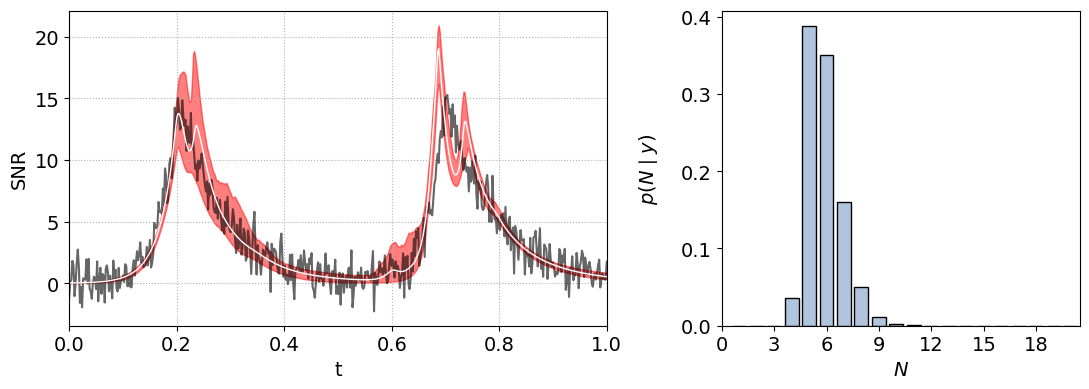

torch.Size([500])


In [94]:
# posterior samples that include all sampled component numbers
posterior_param_samples = path.p_data.prior.samples_as_dict(final_snapshot)

posterior_curve_samples = BatchedModel(
    device=device, 
    **{
        'time':torch.linspace(0, t_max, observed_counts.shape[0]), 
        'burstparams':posterior_param_samples,
        'ybkg':YBKG,
        'ncomp':Ns
        }
        ).get_flux()

import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(11, 4))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1])  # first subplot wider

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

ax1.plot(np.linspace(0, 1, observed_counts.shape[0]), observed_counts.flatten().cpu(),'k-', alpha=0.6,  label='observed flux')
sample_colors=['pink', 'yellow', 'orange', 'purple', 'green', 'cyan', 'red', 'grey', 'magenta', 'blue']
# for i in range(num_samples):
#     random_idx = i#torch.randint(0, num_samples, size=(1,)).item()
#     ax1.plot(
#         np.linspace(0, 1, observed_counts.shape[0]), 
#         posterior_curve_samples[random_idx].cpu(), 
#         alpha=0.07, 
#         color='red',
#         # alpha=1,
#         # color = sample_colors[int(Ns[random_idx].item()) - 1], 
#         label='posterior samples' if i==0 else ''
#         )


# plot mean curve
plot_mean =True 
if plot_mean:
    mean_profile = torch.mean(posterior_curve_samples[0:num_samples], dim=0).cpu()
    time_ = np.linspace(0, t_max, observed_counts.shape[0])
    ax1.plot(time_, mean_profile, color='white', label='mean profile', linewidth=1)

    # 95% percentile
    q1 = torch.quantile(posterior_curve_samples, 0.025, dim=0).cpu()
    q3 = torch.quantile(posterior_curve_samples, 0.975, dim=0).cpu()
    iqr = q3 - q1
    ax1.fill_between(time_, q1, q3, color='red', alpha=0.5, label='std profile')

# name = filepath.split('/')[-1].split('_')[0]
# ax1.set_title(name, fontsize=16)
ax1.grid(linestyle='dotted')
ax1.set_ylabel('SNR', fontsize=14)
ax1.set_xlabel('t', fontsize=14)
ax1.set_xlim(0,1)
ax1.tick_params(axis='both', labelsize=14)

ax2.bar(
    range(1, len(p_N.cpu().detach().numpy())+1), 
    height=p_N.cpu().detach().numpy(), 
    # color=sample_colors,
    color='lightsteelblue', 
    edgecolor='black',    # color of the bar edge
    linewidth=1,
    label=range(1, 21)
    )
# ax2.legend()
ax2.set_xlabel("$N$", fontsize=14)
ax2.set_ylabel('$p(N\mid y)$', fontsize=14, labelpad=15)
ax2.tick_params(axis='both', labelsize=14)
plt.xlim(0, 20.5)
import matplotlib.ticker as mticker
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(f'poor_inference_at_low_res.png', dpi=300)

plt.show()
print(observed_counts.shape)